In [1]:
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import numpy as np
from PIL import Image
import random
import os
import h5py
from tqdm import tqdm
import multiprocessing
import h5py

In [2]:
path = '/mnt/storage-data3/wangcheng/data/test_data/fits_test/test.h5'

In [3]:
def plot_images(images, labels,objids,ras,decs):   
    fig, axs = plt.subplots(4, 4, figsize=(20, 20))
    random_indices = random.sample(range(len(images)), 16)
    # 遍历选中的图像
    for i, ax in enumerate(axs.flatten()):
        # 从HDF5文件中获取图像数据和对应的标签
        img_data = images[random_indices[i]]
        label = labels[random_indices[i]]

        times = 0.04
        # 图像处理
        img_data[0] = img_data[0] * 12.50 * times
        img_data[1] = img_data[1] * 7.143 * times
        img_data[2] = img_data[2] * 5.263 * times
        img_data = np.clip(img_data, 0, 1)

        # 显示图像和标签
        ax.imshow(img_data.transpose(1, 2, 0))
        if label is not None:
            ax.set_title(f'({ras[random_indices[i]]},{decs[random_indices[i]]})')
        ax.axis('off')

    plt.show()

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # 如果你需要更美观的图表，可以使用 seaborn

def images_compare(images, labels, ras, decs,objids,times_list,num_images=4):   
    
    num_times = len(times_list)  # time 值的数量
    
    # 创建子图，行数为随机图像数量，列数为 time 值数量
    fig, axs = plt.subplots(num_images, num_times, figsize=(num_times * 5, num_images * 5))
    
    # 随机选择 num_images 个图像的索引
    random_indices = random.sample(range(len(images)), num_images)
    
    for row in range(num_images):
        img_idx = random_indices[row]
        img_data = images[img_idx].copy()  # 复制图像数据，避免修改原始数据
        label = labels[img_idx]
        ra = ras[img_idx]
        dec = decs[img_idx]
        objid = objids[img_idx]
        
        for col, time in enumerate(times_list):
            # 对图像进行处理
            processed_img = img_data.copy()
            processed_img[0] = processed_img[0] * 12.50 * time
            processed_img[1] = processed_img[1] * 7.143 * time
            processed_img[2] = processed_img[2] * 5.263 * time
            processed_img = np.clip(processed_img, 0, 1)  # 保证像素值在 [0, 1] 之间
            
            # 显示图像
            ax = axs[row, col]  # 获取当前子图
            ax.imshow(processed_img.transpose(1, 2, 0))
            ax.set_title(f'time={time}\n {objid}', fontsize=12)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()


In [33]:
import numpy as np
import matplotlib.pyplot as plt

def images_compare_specified(images, labels, ras, decs, objids, specified_objids, times_list):
    """
    根据指定的 objid 列表绘制图像，并在不同 time 值下展示效果。

    参数：
    - images: 图像数据，形状为 (num_images, 3, H, W)
    - labels: 图像标签，形状为 (num_images,)
    - ras: 图像的 RA 值，形状为 (num_images,)
    - decs: 图像的 Dec 值，形状为 (num_images,)
    - objids: 图像对应的 objid 列表，与 images 一一对应
    - specified_objids: 指定的 objid 列表，用于选择要展示的图像
    - times_list: 不同的 time 值列表，用于图像处理
    """

    num_images = len(specified_objids)
    num_times = len(times_list)

    # 创建子图，行数为指定图像数量，列数为 time 值数量
    fig, axs = plt.subplots(num_images, num_times, figsize=(num_times * 5, num_images * 5))

    # 如果只有一张图像或一列，扩展 axs 的维度以统一处理
    if num_images == 1:
        axs = np.expand_dims(axs, axis=0)
    if num_times == 1:
        axs = np.expand_dims(axs, axis=1)

    for row, objid in enumerate(specified_objids):
        # 根据 objid 找到它在 objids 中的索引位置
        try:
            img_idx = objids.index(objid)
        except ValueError:
            print(f'objid {objid} 不存在于 objids 列表中。跳过此 objid。')
            continue

        img_data = images[img_idx].copy()
        label = labels[img_idx]
        ra = ras[img_idx]
        dec = decs[img_idx]

        for col, time in enumerate(times_list):
            # 图像处理
            processed_img = img_data.copy()
            processed_img[0] = processed_img[0] * 12.50 * time
            processed_img[1] = processed_img[1] * 7.143 * time
            processed_img[2] = processed_img[2] * 5.263 * time
            processed_img = np.clip(processed_img, 0, 1)  # 保证像素值在 [0, 1] 之间

            # 显示图像
            ax = axs[row, col]
            ax.imshow(processed_img.transpose(1, 2, 0))
            ax.set_title(f'objid={objid}\ntime={time}\n({ra:.2f}, {dec:.2f})', fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    plt.show()


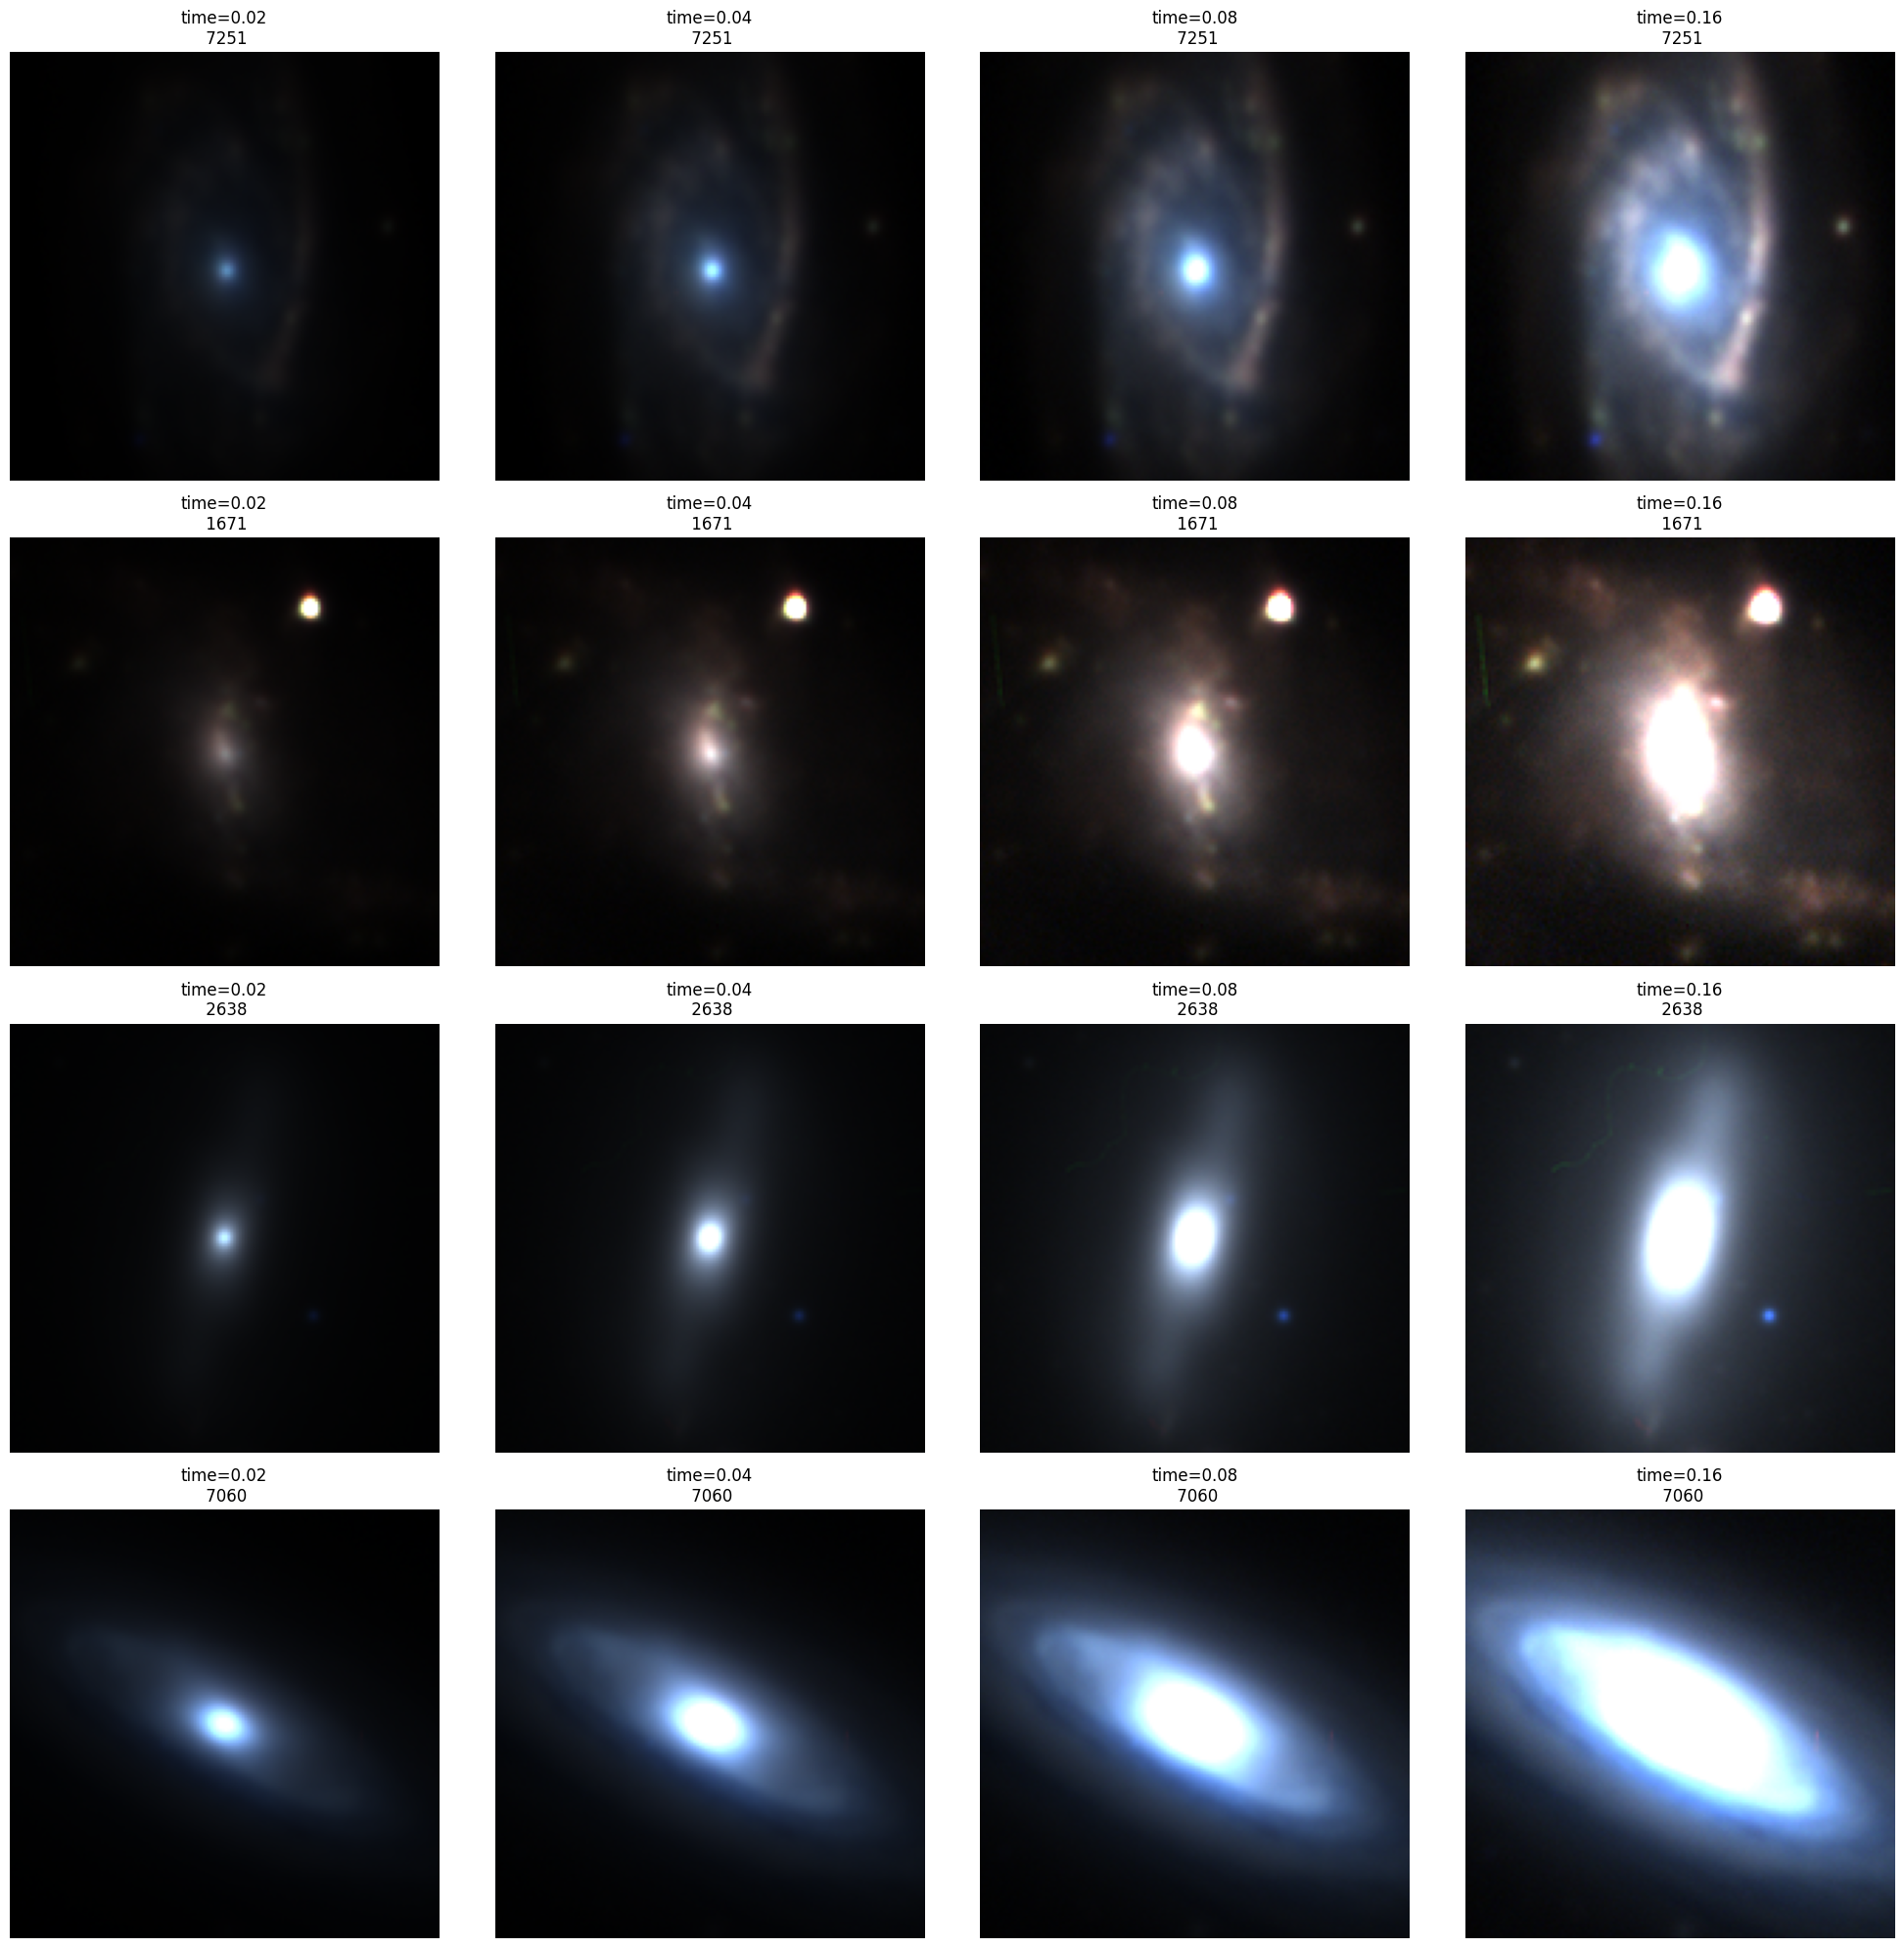

In [6]:
# 打开并读取文件
with h5py.File(path, 'r') as new_file:
    # 直接通过数据集名称访问数据
    images = new_file['images']
    objids = new_file['objid']
    ras = new_file['ra']
    decs = new_file['dec']
    labels = new_file['label']

    objids_list =[4325
    ,2055
    ,16152
    ,3463
    ,4099
    ,4213]

    time_list =[0.02,0.04,0.08,0.16]

    images_compare(images, labels, ras, decs, objids, time_list, num_images=4)        
    # images_compare_specified(images, labels, ras, decs, objids, objids_list, time_list)

In [ ]:
4325
2055
16152
3463
4099
4213

In [26]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def images_compare_specified(images, labels, ras, decs, objid_list, specified_objids, times_list):
    """
    绘制指定 objid 对应图像在不同 time 值下的对比图。

    参数：
    - images: 图像数据，形状为 (num_images, 3, H, W)
    - labels: 图像标签，形状为 (num_images,)
    - ras: 图像的 RA 值，形状为 (num_images,)
    - decs: 图像的 Dec 值，形状为 (num_images,)
    - objid_list: 图像对应的 objid 列表，长度为 num_images
    - specified_objids: 指定的 objid 列表，用于选择要展示的图像
    - times_list: 不同的 time 值列表，用于图像处理
    """

    num_images = len(specified_objids)
    num_times = len(times_list)

    # 创建子图，行数为指定图像数量，列数为 time 值数量
    fig, axs = plt.subplots(num_images, num_times, figsize=(num_times * 5, num_images * 5))

    # 如果只有一张图像，则 axs 不是二维数组，需要处理
    if num_images == 1:
        axs = np.expand_dims(axs, axis=0)
    if num_times == 1:
        axs = np.expand_dims(axs, axis=1)

    for row, objid in enumerate(specified_objids):
        try:
            img_idx = objid_list.index(objid)
        except ValueError:
            print(f'objid {objid} 不存在于 objid_list 中。跳过此 objid。')
            continue

        img_data = images[img_idx].copy()
        label = labels[img_idx]
        ra = ras[img_idx]
        dec = decs[img_idx]

        for col, time in enumerate(times_list):
            # 图像处理
            processed_img = img_data.copy()
            processed_img[0] = processed_img[0] * 12.50 * time
            processed_img[1] = processed_img[1] * 7.143 * time
            processed_img[2] = processed_img[2] * 5.263 * time
            processed_img = np.clip(processed_img, 0, 1)  # 保证像素值在 [0, 1] 之间

            # 显示图像
            ax = axs[row, col]
            ax.imshow(processed_img.transpose(1, 2, 0))
            ax.set_title(f'objid={objid}\ntime={time}\n({ra:.2f}, {dec:.2f})', fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    plt.show()
